In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [10]:
def hist(img, title="Histograma"):
    plt.figure(figsize=(5, 4))
    plt.hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    plt.title(title)
    plt.xlabel("Intensidade")
    plt.ylabel("Número de pixels")
    plt.tight_layout()
    plt.show()


def plot_comparison(bef, aft, title_bef, title_aft, img_name):
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))

    ax[0, 0].imshow(bef, cmap="gray", vmin=0, vmax=255)
    ax[0, 0].set_title(title_bef)
    ax[0, 0].axis("off")

    ax[0, 1].imshow(aft, cmap="gray", vmin=0, vmax=255)
    ax[0, 1].set_title(title_aft)
    ax[0, 1].axis("off")

    ax[1, 0].hist(bef.ravel(), bins=256, range=(0, 255), color="gray")
    ax[1, 0].set_title(f"Histograma - {title_bef}")
    ax[1, 0].set_xlabel("Intensidade")
    ax[1, 0].set_ylabel("Número de pixels")

    ax[1, 1].hist(aft.ravel(), bins=256, range=(0, 255), color="gray")
    ax[1, 1].set_title(f"Histograma - {title_aft}")
    ax[1, 1].set_xlabel("Intensidade")
    ax[1, 1].set_ylabel("Número de pixels")

    plt.tight_layout()
    plt.savefig(img_name, dpi=200, bbox_inches="tight")
    plt.show()


def stats(img):
    media = img.mean()
    desvio = img.std()
    pct_escuros = (img < 50).mean() * 100
    pct_claros = (img > 200).mean() * 100
    print(f"Média de intensidade: {media:.1f}")
    print(f"Desvio-padrão:        {desvio:.1f}")
    print(f"% de pixels < 50  (região escura): {pct_escuros:.1f}%")
    print(f"% de pixels > 200 (região clara):  {pct_claros:.1f}%")
    return media, desvio, pct_escuros, pct_claros


def plus_contrast(img, L=None, H=None):
    if L is None:
        L = int(img.min())
    if H is None:
        H = int(img.max())
    img_f = img.astype(np.float32)
    saida = (img_f - L) * (255.0 / (H - L))
    return np.clip(saida, 0, 255).astype(np.uint8)


def equalize(img):
    return cv2.equalizeHist(img)


def gamma_correction(img, gamma):
    inv_gamma = 1.0 / gamma
    tabela = np.array(
        [((i / 255.0) ** inv_gamma) * 255 for i in range(256)]
    ).astype(np.uint8)
    return cv2.LUT(img, tabela)


def load_grayscale_image(title_img, title_hist):
    uploaded = files.upload()
    name = next(iter(uploaded))
    img_bgr = cv2.imread(name)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
    plt.title(title_img)
    plt.axis("off")
    plt.show()

    hist(img_gray, title_hist)
    stats(img_gray)
    return img_gray



## Imagem Escura


Saving bigodes_noturna.jpeg to bigodes_noturna (1).jpeg


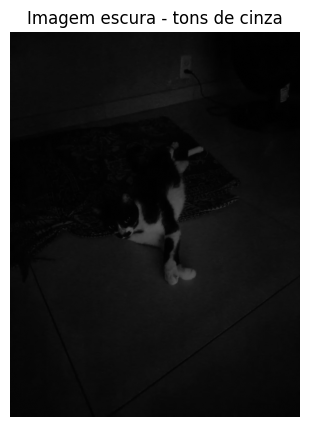

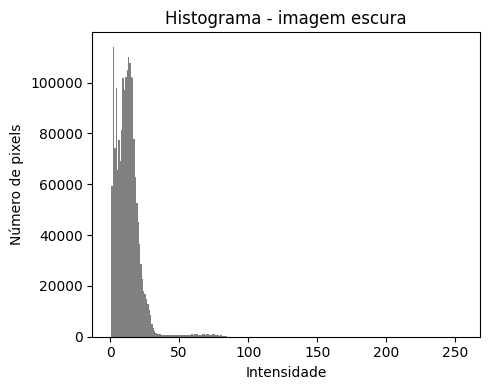

Média de intensidade: 12.6
Desvio-padrão:        9.4
% de pixels < 50  (região escura): 98.7%
% de pixels > 200 (região clara):  0.0%


In [11]:
img_dark_gray = load_grayscale_image(
    "Imagem escura - tons de cinza",
    "Histograma - imagem escura",
)


O histograma confirma uma forte subexposição: a média de intensidade é de apenas 12,6, com desvio-padrão baixo de 9,4, e 98,7% dos pixels estão abaixo do nível 50 (região escura), enquanto 0% ultrapassa a quantidade de 200 pixels. A distribuição fica quase inteiramente concentrada nos primeiros níveis de cinza, evidenciando bastante a presença de sombra na imagem

Gamma 2.5: como praticamente toda a massa de pixels está concentrada na região escura e não há pixels claros, uma correção gama não linear com y > 1 empurra essa massa escura em direção aos tons médios, revelando alguns detalhes que não são t~çao facilmente vistos na imagem, sem risco de distorcer muito elas, já que eles praticamente não existem na imagem.

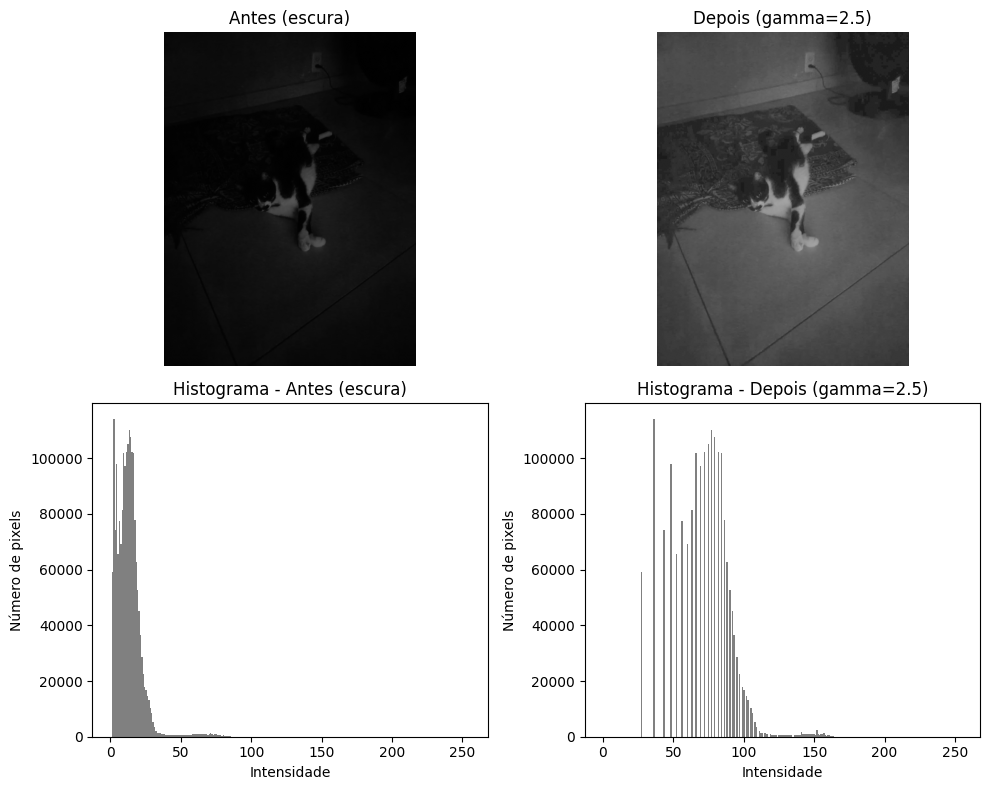

In [12]:
gamma_dark = 2.5
img_dark_corr = gamma_correction(img_dark_gray, gamma_dark)

plot_comparison(
    img_dark_gray, img_dark_corr,
    "Antes (escura)", f"Depois (gamma={gamma_dark})",
    "comparacao_escura.png",
)



## Imagem Clara


Saving bigodes_flash.jpeg to bigodes_flash.jpeg


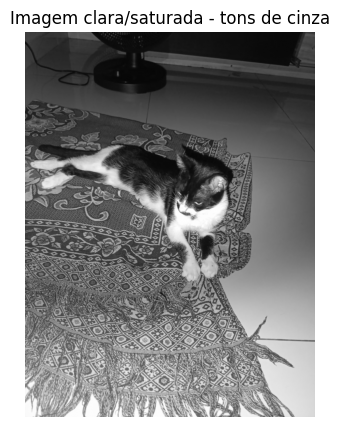

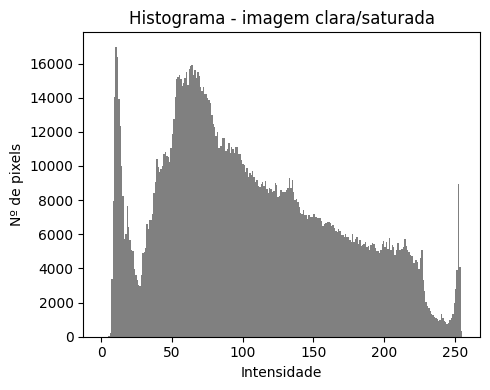

Média de intensidade: 106.4
Desvio-padrão:        61.3
% de pixels < 50  (região escura): 17.9%
% de pixels > 200 (região clara):  9.7%


In [9]:
img_bright_gray = load_grayscale_image(
    "Imagem clara/saturada - tons de cinza",
    "Histograma - imagem clara/saturada",
)


O histograma desta imagem (feita com flash) é bem mais irregular que o da anterior: a média fica em 106,4 e o desvio-padrão é alto (61,3), refletindo o forte contraste entre as áreas iluminadas e as não iluminadas pelo flash. Há uma parcela relevante de pixels muito escuros (17,9% abaixo de 50, no fundo sem luz direta) e também de pixels muito claros (9,7% acima de 200, distorcidos pelo flash sobre a gata Bigodes e o tapete), com boa quantidade de tons médios entre esses dois extremos.

Gamma 0.4: como uma parte considerável dos pixels já está estourada pelo flash e o restante fica espalhado por tons médios e escuros, um y < 1 comprime a região clara e reduz o brilho geral da imagem, diminuindo o excesso de luz do flash. O efeito princiapl é escurecer também as áreas que já estavam nas partes mais escuras da imagem

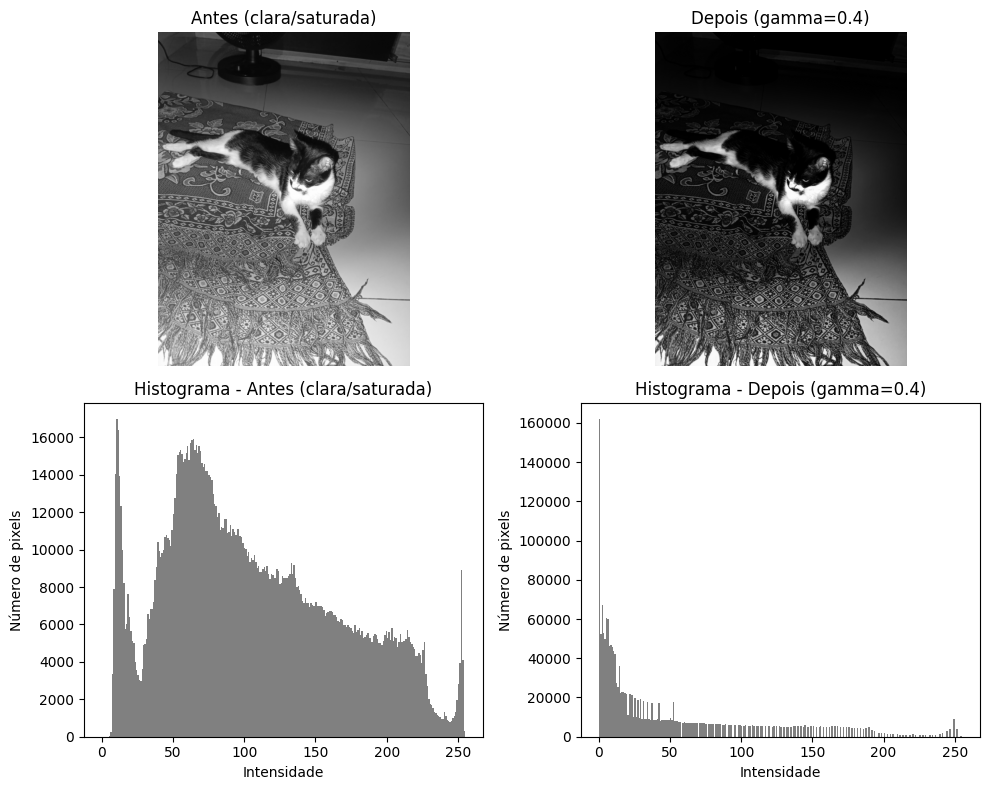

In [13]:
gamma_bright = 0.4
img_bright_corr = gamma_correction(img_bright_gray, gamma_bright)

plot_comparison(
    img_bright_gray, img_bright_corr,
    "Antes (clara/saturada)", f"Depois (gamma={gamma_bright})",
    "comparacao_clara.png",
)



## Imagem bem exposta


Saving bigodes_luz.jpeg to bigodes_luz.jpeg


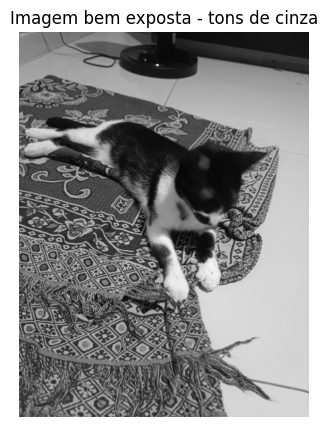

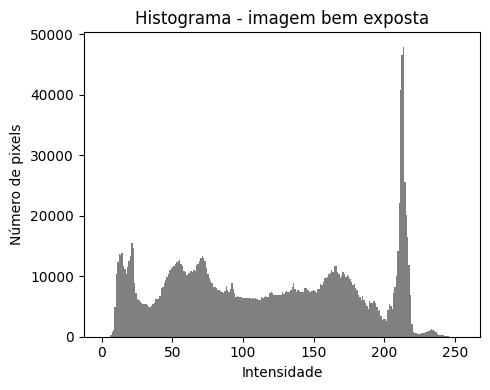

Média de intensidade: 117.7
Desvio-padrão:        66.2
% de pixels < 50  (região escura): 18.8%
% de pixels > 200 (região clara):  16.7%


In [14]:
img_normal_gray = load_grayscale_image(
    "Imagem bem exposta - tons de cinza",
    "Histograma - imagem bem exposta",
)


O histograma desta imagem mostra um equilíbrio bem melhor que os anteriores: média de 117,7 e desvio-padrão de 66,2, com os pixels distribuídos por quase toda a faixa de intensidades (18,8% na região escura e 16,7% na região clara). Existe um pico pronunciado próximo de 210, referente a uma superfície clara ao fundo, mas sombras, tons médios e realces aparecem bem representados, sem grandes cortes (clipping) em 0 ou 255.

Sendo uma imagem já bem exposta, a escolha é a expansão de contraste: como os valores mínimo e máximo atuais não chegam a tocar 0 e 255, essa técnica apenas estica a faixa existente até os extremos, removendo qualquer leve efeito de fosco sem distorcer o equilíbrio entre sombras e realces que essa imagem já possui.

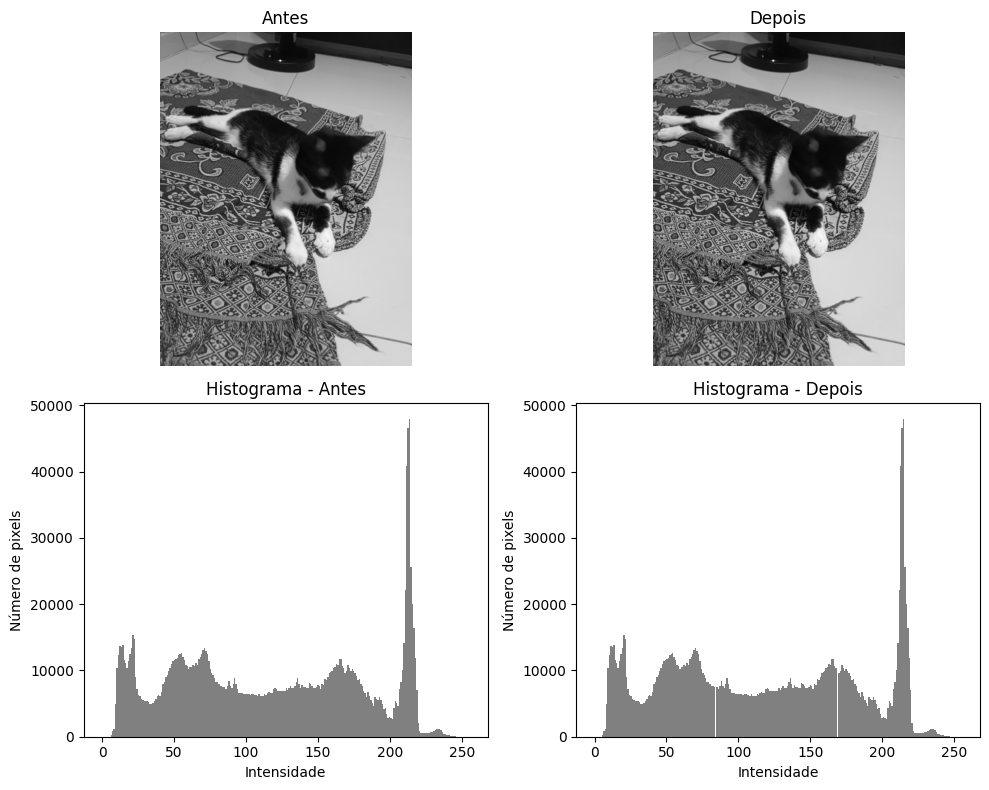

In [15]:
img_normal_equalized = plus_contrast(img_normal_gray)

plot_comparison(
    img_normal_gray, img_normal_equalized,
    "Antes", "Depois",
    "comparacao_boa.png",
)


A operação fez menos diferença na Imagem 3 (a imagem exposta): como o histograma original já ocupava quase toda a faixa dinâmica, a expansão de contraste apenas esticou levemente os extremos da imagem - uma mudança quase imperceptível.

Já as imagens 1 e 2 tinham histogramas fortemente divididos ou com extremos (a 1 quase toda concentrada abaixo do nível 50; a 2 dividida entre sombras e realces altos por causa do flash) e por isso precisaram da correção gama não linear para recuperar informação visível.